# Spaceship Titanic 과제

- 목적: `Transported` 여부를 예측하는 이진 분류 문제 해결
- 목표: Kaggle Public Score `0.805` 이상 달성
- 구성: 개요, 데이터 이해, 결측치 확인, 시각화, 전처리, 모델 학습, 결과 분석, Summary, 회고



# 0. 라이브러리 불러오기


In [23]:
!pip install catboost missingno

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from catboost import CatBoostClassifier


# 시각화 기본 설정
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.set_option("display.max_columns", 100)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 55.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]


# 1. 개요


이 과제는 승객의 여러 정보(HomePlanet, CryoSleep, Cabin, 소비 금액 등)를 바탕으로
해당 승객이 다른 차원으로 이동되었는지(Transported)를 예측하는 이진 분류 문제이다.
평가 지표는 Accuracy이며, 이번 과제의 목표는 Kaggle Public Score 0.805 이상 달성이다.

아래 분석은 다음 순서로 진행한다.
1) 데이터 구조 및 결측치 확인
2) 시각화를 통한 변수 해석
3) 논리적 근거가 있는 전처리 및 피처 엔지니어링
4) CatBoost 모델 학습
5) 검증 결과 및 중요 변수 해석
6) submission.csv 생성

# 2. 데이터 경로 설정

In [2]:
TRAIN_PATH = "~/work/AIFFEL_quest_eng/Main_Quest/Quest01/train.csv"
TEST_PATH = "~/work/AIFFEL_quest_eng/Main_Quest/Quest01/test.csv"
SUBMISSION_PATH = "~/work/AIFFEL_quest_eng/Main_Quest/Quest01/sample_submission.csv"

# 3. 데이터 불러오기

In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("train shape:", train.shape)
print("test shape:", test.shape)
display(train.head())

train shape: (8693, 14)
test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# 4. 데이터 이해

- 학습 데이터는 8,693개, 테스트 데이터는 4,277개로 구성되어 있다.
- 타깃 변수는 Transported이며 True/False의 이진 분류 문제이다.
- 범주형 변수와 수치형 변수가 함께 존재하고, 여러 변수에 결측치가 포함되어 있다.

In [8]:
print(train.info())
display(train.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,8693,8693,9280_02,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomePlanet,8492,3,Earth,4602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CryoSleep,8476,2,False,5439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,8494,6560,G/734/S,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,8511,3,TRAPPIST-1e,5915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,8514.0,NaN,NaN,NaN,28.82793,14.489021,0.0,19.0,27.0,38.0,79.0
VIP,8490,2,False,8291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RoomService,8512.0,NaN,NaN,NaN,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,NaN,NaN,NaN,458.077203,1611.48924,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,NaN,NaN,NaN,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0


# 5. 결측치 확인

- HomePlanet, CryoSleep, Cabin, VIP, 소비 금액 변수들에 결측치가 존재했다.
- 결측 비율이 매우 높지는 않지만 여러 열에 분산되어 있어 단순 행 삭제보다는 변수 간 관계를 활용한 보정이 더 적절하다고 판단했다.

train missing values


CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
dtype: int64

test missing values


FoodCourt       106
Spa             101
Cabin           100
ShoppingMall     98
Name             94
VIP              93
CryoSleep        93
Destination      92
Age              91
HomePlanet       87
RoomService      82
VRDeck           80
dtype: int64

<Figure size 1000x400 with 0 Axes>

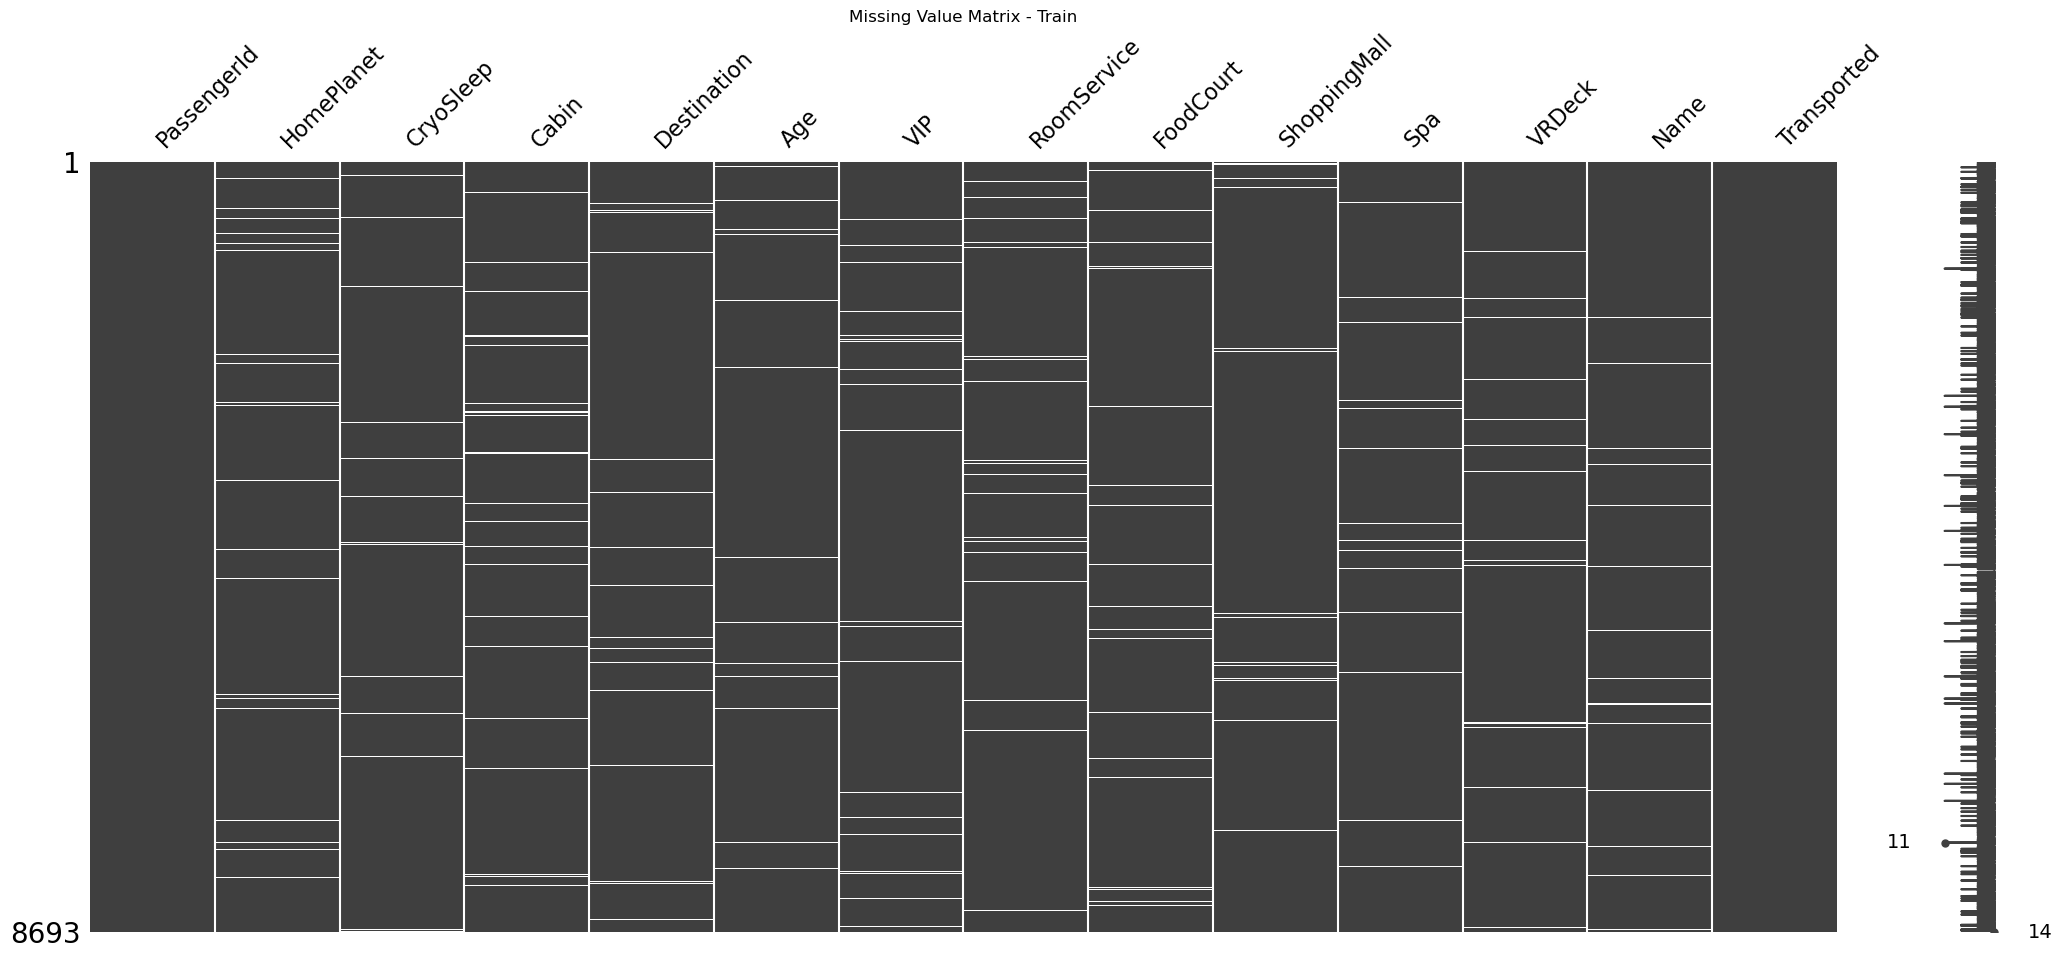

In [7]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test = test.isnull().sum().sort_values(ascending=False)

print("train missing values")
display(missing_train[missing_train > 0])

print("test missing values")
display(missing_test[missing_test > 0])

plt.figure(figsize=(10, 4))
msno.matrix(train)
plt.title("Missing Value Matrix - Train")
plt.show()

# 6. 기본 시각화

- 이동되지 않은 승객은 일부 소비 항목에서 지출이 더 큰 경향을 보였다.
- 따라서 개별 소비 변수뿐 아니라 총 소비 금액을 파생 변수로 만드는 것이 유의미하다고 판단했다.

# 6-1. 타깃 분포

- 타깃 분포는 큰 불균형 없이 비교적 고르게 분포했다.
- 따라서 Accuracy를 평가 지표로 사용하기에 무리가 없다고 판단했다.

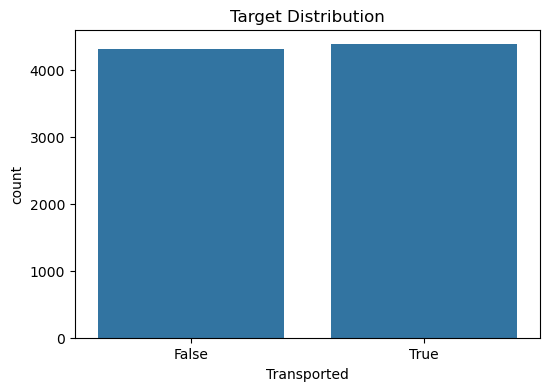

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Transported")
plt.title("Target Distribution")
plt.show()

print(train["Transported"].value_counts(normalize=True))

# 6-2. CryoSleep와 Transported 관계

- CryoSleep=True인 승객은 Transported 비율이 매우 높았다.
- 이 변수는 예측에 핵심적인 변수일 가능성이 높다.

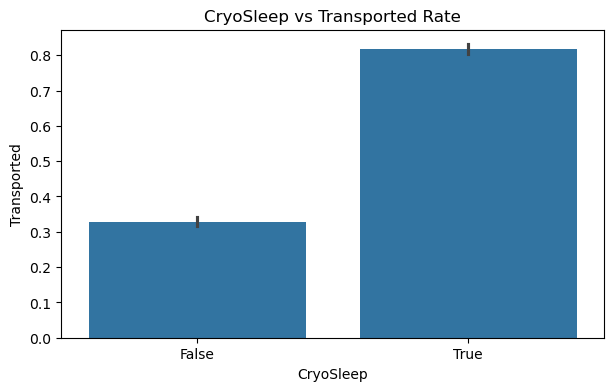

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=train, x="CryoSleep", y="Transported")
plt.title("CryoSleep vs Transported Rate")
plt.show()

# 7-3. HomePlanet과 Transported 관계

- 출발 행성에 따라 이동 비율이 다르게 나타났다.
- 따라서 HomePlanet은 단순 인적 정보가 아니라 예측에 유의미한 범주형 변수라고 볼 수 있다.

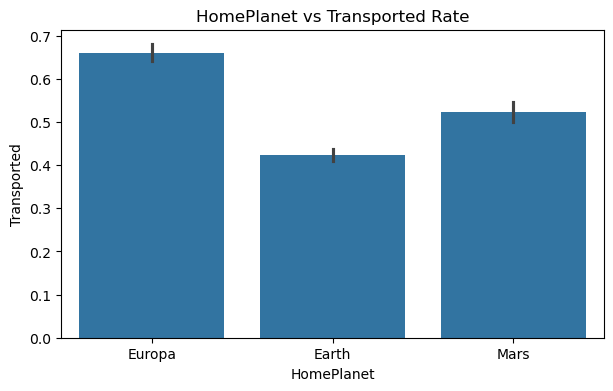

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=train, x="HomePlanet", y="Transported")
plt.title("HomePlanet vs Transported Rate")
plt.show()

# 7-4. Destination과 Transported 관계

- 목적지에 따라서도 타깃 비율 차이가 나타났다.
- 목적지 정보는 승객 그룹의 특성을 반영할 수 있는 변수로 해석할 수 있다.

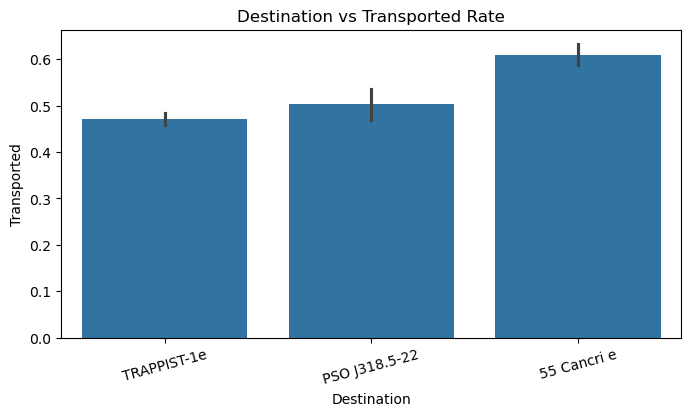

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(data=train, x="Destination", y="Transported")
plt.title("Destination vs Transported Rate")
plt.xticks(rotation=15)
plt.show()

# 7-5. Age 분포

- 연령 분포를 보면 특정 연령대에서 이동 비율이 더 높게 보인다.
- Age는 단독 변수로도 의미가 있지만, CryoSleep이나 소비 변수와 함께 볼 때 더 유용할 수 있다.

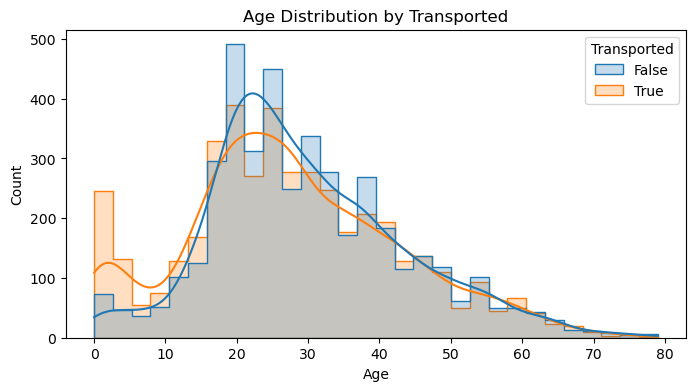

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(data=train, x="Age", hue="Transported", bins=30, kde=True, element="step")
plt.title("Age Distribution by Transported")
plt.show()

# 7-6. 소비 변수 분포

- 소비 변수들은 공통적으로 치우친 분포를 보였고, 일부 승객에게 큰 지출이 집중되어 있었다.
- Transported=False 집단에서 소비 금액이 더 큰 경향이 나타났으며, Transported=True 집단은 무지출 또는 저지출 비율이 높았다.
- 이를 바탕으로 전처리 과정에서 소비 변수들의 합인 TotalSpend를 생성해 모델 입력 변수로 활용했다.

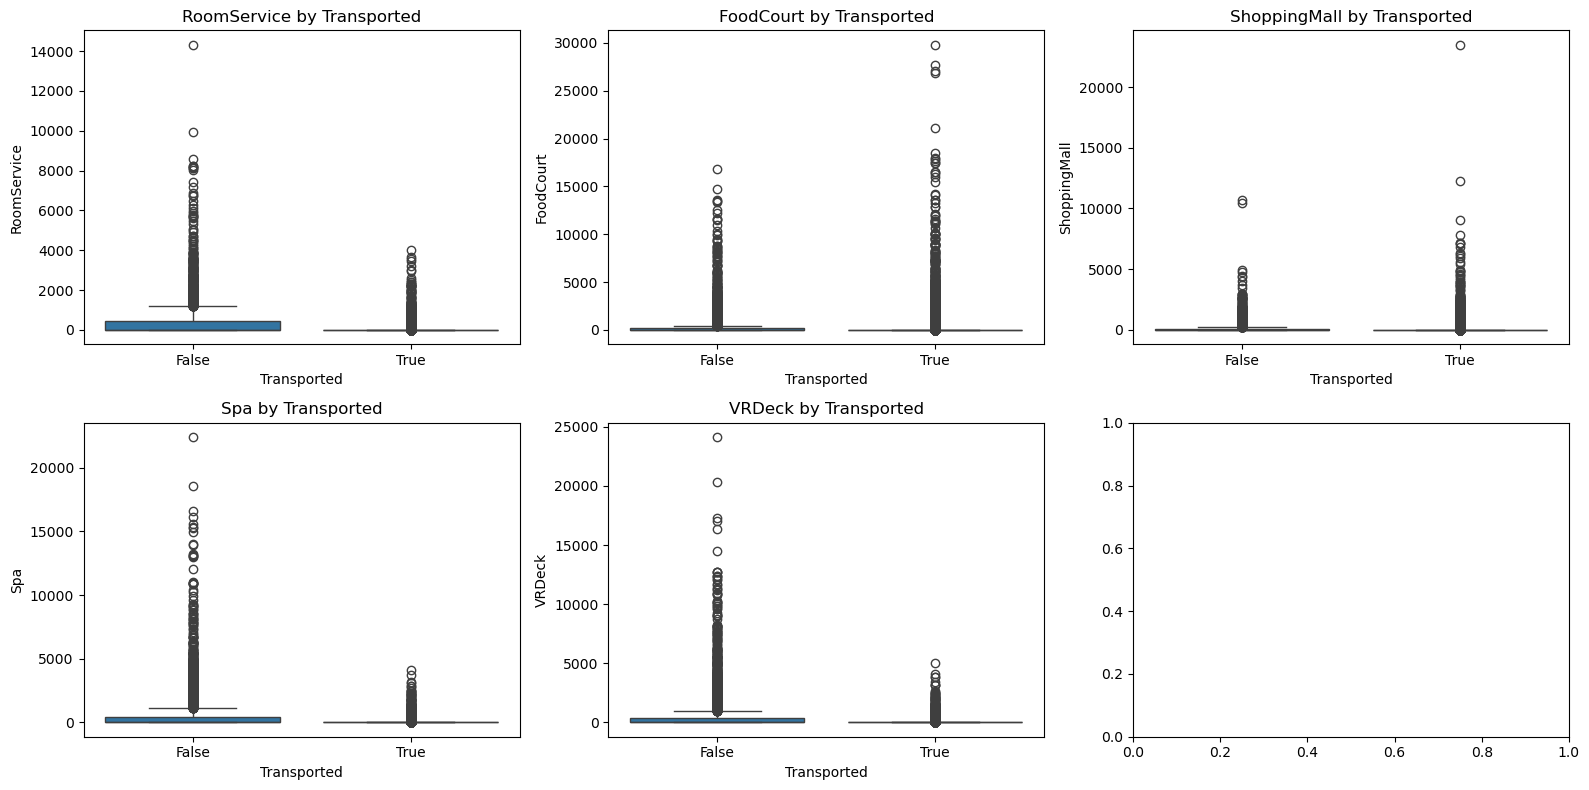

In [15]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(spend_cols):
    sns.boxplot(data=train, x="Transported", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Transported")
plt.tight_layout()
plt.show()

# 8. 전처리 및 피처 엔지니어링 함수

전처리의 핵심 아이디어는 다음과 같다.
- PassengerId는 그룹 정보를 포함하므로 group_id를 분리해 group_size를 만들 수 있다.
- Name은 고유값이 많아 그대로 사용하기보다, 가족 단위 정보를 반영할 수 있는 Surname으로 변환하여 활용하였다.
- Cabin 변수는 Deck/CabinNum/Side 형태의 문자열로 구성되어 있어 / 기준으로 분리하였다. Cabin 문자열은 그대로 두기보다 deck / cabin_num / side로 나누는 것이 더 해석 가능하다.
- 소비 변수는 전체 합계를 만드는 편이 소비 성향을 더 잘 반영한다.
- CryoSleep 승객은 소비가 거의 없다는 가정을 결측 보정에 활용할 수 있다.
- Age를 그대로 사용하는 것과 별개로, 연령대별 특성을 해석하기 쉽도록 AgeBand를 생성하였다.

In [17]:
def feature_engineering(df):
    df = df.copy()

    # PassengerId에서 그룹 정보 추출
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupMember"] = df["PassengerId"].str.split("_").str[1]

    # 같은 그룹 승객 수
    group_size_map = df["Group"].value_counts().to_dict()
    df["GroupSize"] = df["Group"].map(group_size_map)
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    # Name에서 성 추출
    df["Surname"] = df["Name"].str.split().str[-1]

    # Cabin 분해
    cabin_split = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin_split[0]
    df["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    df["Side"] = cabin_split[2]

    # 소비 금액 합계
    for col in spend_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["TotalSpend"] = df[spend_cols].sum(axis=1, skipna=True)
    df["NoSpending"] = (df["TotalSpend"] == 0).astype(int)

    # 나이 구간화
    df["AgeBand"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 25, 40, 60, 80],
        labels=["Child", "Teen", "Youth", "Adult", "Middle", "Senior"]
    )d

    return df


combined = pd.concat(
    [train.drop(columns=["Transported"]), test],
    axis=0,
    ignore_index=True
)

combined = feature_engineering(combined)
y = train["Transported"].astype(int)

display(combined.head())


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,GroupMember,GroupSize,IsAlone,Surname,Deck,CabinNum,Side,TotalSpend,NoSpending,AgeBand
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,01,1,1,Ofracculy,B,0.0,P,0.0,1,Adult
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,01,1,1,Vines,F,0.0,S,736.0,0,Youth
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,01,2,0,Susent,A,0.0,S,10383.0,0,Middle
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,02,2,0,Susent,A,0.0,S,5176.0,0,Adult
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,01,1,1,Santantines,F,1.0,S,1091.0,0,Teen


# 9. 결측치 보정

아래 보정은 단순 최빈값 대체보다 변수 간 논리를 반영하는 데 초점을 맞췄다.  
- CryoSleep=True이면 선내 소비가 거의 없을 가능성이 높다고 보고, 해당 승객의 소비 변수 결측치는 0으로 대체하였다.
- 소비 금액이 존재하는데 CryoSleep이 결측인 경우에는 CryoSleep=False로, 소비 금액이 모두 0인데 CryoSleep이 결측인 경우에는 CryoSleep=True로 보정하였다.
- HomePlanet과 Destination은 같은 그룹 승객끼리 동일할 가능성이 높다고 판단하여, 그룹별 최빈값을 이용해 우선 보정하였다.
- 그룹 정보만으로 채워지지 않는 HomePlanet은 Deck 정보를 참고해 추가 보정하였고, 이후에도 남는 값은 전체 최빈값으로 대체하였다.
- VIP는 결측 비율이 크지 않고 전체 분포상 False 비중이 높아 False로 대체하였다.
- Deck와 Side는 객실 위치를 나타내는 범주형 변수이므로, 결측을 제거하지 않고 Unknown이라는 별도 범주로 보존하였다.
- CabinNum은 먼저 같은 Deck 내부의 중앙값으로 채우고, 이후에도 남는 결측치는 전체 중앙값으로 대체하였다.
- 소비 금액 변수와 Age는 HomePlanet과 CryoSleep 조합별 중앙값으로 우선 보정한 뒤, 남는 값은 전체 중앙값으로 대체하였다.
- Name과 Surname의 결측은 Unknown으로 처리하였다.
- 결측치 보정 이후에는 TotalSpend, NoSpending, AgeBand를 다시 계산하고, 일부 변수의 자료형을 모델 학습에 맞게 정리하였다.

In [27]:
def fill_missing_values(df):
    df = df.copy()

    # CryoSleep가 True인 경우 소비 결측을 0으로 채움
    cryo_true_mask = df["CryoSleep"] == True
    df.loc[cryo_true_mask, spend_cols] = df.loc[cryo_true_mask, spend_cols].fillna(0)

    # 소비가 하나라도 있으면 CryoSleep은 False일 가능성이 높음
    spend_sum_temp = df[spend_cols].sum(axis=1, skipna=True)
    has_spending = spend_sum_temp > 0
    df.loc[df["CryoSleep"].isnull() & has_spending, "CryoSleep"] = False

    # 소비가 전부 0이고 CryoSleep 결측이면 True로 보정
    all_zero_spending = (df[spend_cols].fillna(0).sum(axis=1) == 0)
    df.loc[df["CryoSleep"].isnull() & all_zero_spending, "CryoSleep"] = True

    # HomePlanet 그룹 기준 보정
    group_homeplanet = df.groupby("Group")["HomePlanet"].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df["HomePlanet"] = df["HomePlanet"].fillna(df["Group"].map(group_homeplanet))

    # Deck 기반 보정: 일반적으로 G는 Earth, A/B/C/T는 Europa 비중이 높음
    deck_homeplanet_map = {
        "G": "Earth",
        "A": "Europa",
        "B": "Europa",
        "C": "Europa",
        "T": "Europa"
    }
    df["HomePlanet"] = df["HomePlanet"].fillna(df["Deck"].map(deck_homeplanet_map))
    df["HomePlanet"] = df["HomePlanet"].fillna(df["HomePlanet"].mode()[0])

    # Destination 그룹 기준 후 최빈값 대체
    group_destination = df.groupby("Group")["Destination"].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df["Destination"] = df["Destination"].fillna(df["Group"].map(group_destination))
    df["Destination"] = df["Destination"].fillna(df["Destination"].mode()[0])

    # VIP는 False가 훨씬 많으므로 False 대체
    df["VIP"] = df["VIP"].fillna(False)

    # Cabin 분해 변수 결측은 Unknown으로 보존
    df["Deck"] = df["Deck"].fillna("Unknown")
    df["Side"] = df["Side"].fillna("Unknown")

    # CabinNum은 Deck별 중앙값으로 보정 후 전체 중앙값 대체
    df["CabinNum"] = df["CabinNum"].fillna(df.groupby("Deck")["CabinNum"].transform("median"))
    df["CabinNum"] = df["CabinNum"].fillna(df["CabinNum"].median())

    # 소비 금액은 HomePlanet + CryoSleep 기준 중앙값으로 보정
    for col in spend_cols:
        df[col] = df[col].fillna(
            df.groupby(["HomePlanet", "CryoSleep"])[col].transform("median")
        )
        df[col] = df[col].fillna(df[col].median())

    # Age는 HomePlanet + CryoSleep 기준 중앙값으로 보정
    df["Age"] = df["Age"].fillna(
        df.groupby(["HomePlanet", "CryoSleep"])["Age"].transform("median")
    )
    df["Age"] = df["Age"].fillna(df["Age"].median())

    # Name, Surname 결측은 Unknown 처리
    df["Name"] = df["Name"].fillna("Unknown Unknown")
    df["Surname"] = df["Surname"].fillna("Unknown")

    # 재계산
    df["TotalSpend"] = df[spend_cols].sum(axis=1)
    df["NoSpending"] = (df["TotalSpend"] == 0).astype(int)
    df["AgeBand"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 25, 40, 60, 80],
        labels=["Child", "Teen", "Youth", "Adult", "Middle", "Senior"]
    )
    df["AgeBand"] = df["AgeBand"].astype(str).replace("nan", "Unknown")

    cat_fill_cols = [
        "HomePlanet", "CryoSleep", "Destination", "VIP",
        "Group", "GroupMember", "Surname", "Deck", "Side", "AgeBand"
    ]
    for col in cat_fill_cols:
        df[col] = df[col].fillna("Unknown").astype(str)

    return df


combined = fill_missing_values(combined)

print("remaining missing values")
display(combined.isnull().sum()[combined.isnull().sum() > 0])


remaining missing values


Cabin    299
dtype: int64

# 10. 추가 시각화

- Deck와 Side에 따라 이동 비율 차이가 나타났다.
- 이는 객실 위치 정보가 중요한 신호일 수 있음을 보여준다.
- TotalSpend가 높은 승객일수록 오히려 Transported 비율이 낮아지는 경향이 관찰되었다.
- 따라서 소비 관련 파생 변수는 모델 성능 개선에 기여할 가능성이 크다.

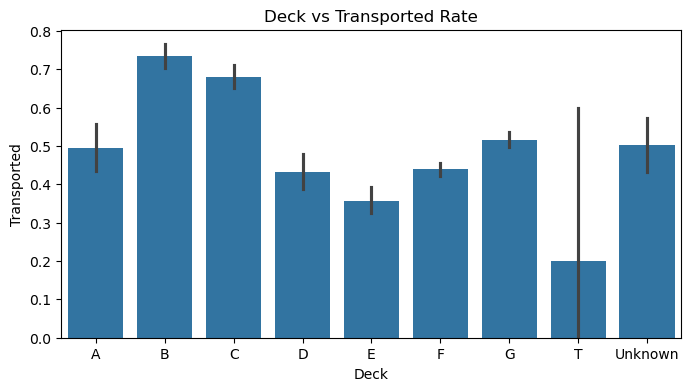

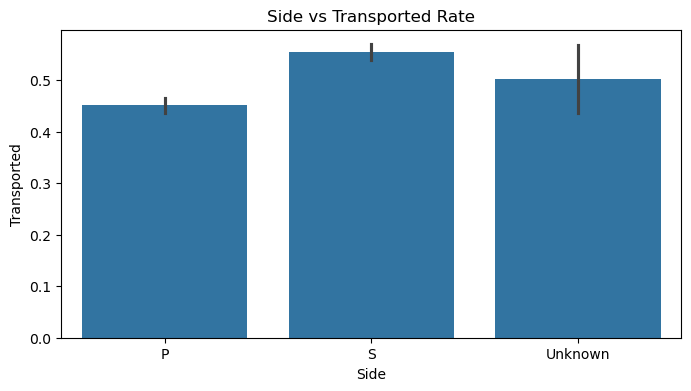

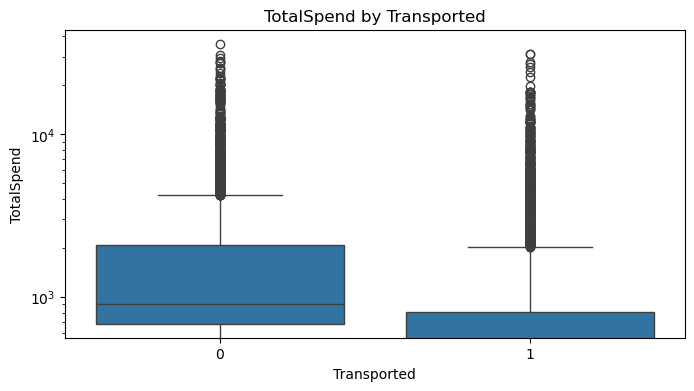

In [19]:
train_fe = combined.iloc[:len(train)].copy()
train_fe["Transported"] = y.values

plt.figure(figsize=(8, 4))
sns.barplot(data=train_fe, x="Deck", y="Transported", order=sorted(train_fe["Deck"].unique()))
plt.title("Deck vs Transported Rate")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=train_fe, x="Side", y="Transported")
plt.title("Side vs Transported Rate")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=train_fe, x="Transported", y="TotalSpend")
plt.title("TotalSpend by Transported")
plt.yscale("log")
plt.show()

# 11. 모델 학습용 데이터 준비

- 전처리 후 모델 입력에 적합하지 않은 PassengerId, Name, Cabin은 제외하고 학습용 데이터를 구성하였다.
- Cabin과 PassengerId에서 파생한 변수들은 유지하여 예측 정보로 활용하였다.
- 이후 학습 데이터를 훈련 세트와 검증 세트로 분리하고, 범주형 변수 목록을 지정해 CatBoost 학습에 사용하였다.

In [28]:
drop_cols = ["PassengerId", "Name", "Cabin"]

X_all = combined.drop(columns=drop_cols)
X_train = X_all.iloc[:len(train)].copy()
X_test = X_all.iloc[len(train):].copy()

categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_feature_idx = [X_train.columns.get_loc(col) for col in categorical_cols]

print("categorical columns:", categorical_cols)
print("train split:", X_tr.shape, y_tr.shape)
print("valid split:", X_val.shape, y_val.shape)

categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Group', 'GroupMember', 'Surname', 'Deck', 'Side', 'AgeBand']
train split: (6954, 21) (6954,)
valid split: (1739, 21) (1739,)


# 12. 모델 학습

CatBoost를 선택한 이유:
- 범주형 변수를 별도 원-핫 인코딩 없이 다루기 쉽다.
- 결측치와 범주형 데이터가 섞인 구조에서 안정적으로 성능이 나온다.

In [29]:
model = CatBoostClassifier(
    iterations=1500,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=200
)

model.fit(
    X_tr,
    y_tr,
    cat_features=cat_feature_idx,
    eval_set=(X_val, y_val),
    use_best_model=True
)


0:	learn: 0.7374173	test: 0.7343301	best: 0.7343301 (0)	total: 80.9ms	remaining: 2m 1s
200:	learn: 0.8242738	test: 0.8033353	best: 0.8039103 (198)	total: 5.58s	remaining: 36.1s
400:	learn: 0.8419615	test: 0.8050604	best: 0.8050604 (389)	total: 10.9s	remaining: 29.9s
600:	learn: 0.8590739	test: 0.8142611	best: 0.8148361 (593)	total: 16.5s	remaining: 24.6s
800:	learn: 0.8734541	test: 0.8205865	best: 0.8205865 (800)	total: 21.8s	remaining: 19s
1000:	learn: 0.8866839	test: 0.8205865	best: 0.8246118 (897)	total: 27.6s	remaining: 13.8s
1200:	learn: 0.8955997	test: 0.8228867	best: 0.8246118 (897)	total: 33.2s	remaining: 8.26s
1400:	learn: 0.9033650	test: 0.8223117	best: 0.8246118 (897)	total: 39.2s	remaining: 2.77s
1499:	learn: 0.9078228	test: 0.8211616	best: 0.8246118 (897)	total: 41.8s	remaining: 0us

bestTest = 0.8246118459
bestIteration = 897

Shrink model to first 898 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=1500, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=200)

# 13. 검증 결과 확인

결과 분석 문장 예시:
- 검증 정확도는 약 0.80 이상으로 확인되었으며, 과제 목표 점수와 유사한 수준의 성능을 기대할 수 있다.
- CryoSleep, TotalSpend, Deck, HomePlanet 등의 변수가 예측에 크게 기여했다.
- 단순 결측치 대체보다 그룹 정보와 Cabin 분해, 소비 합계 파생 변수가 성능 개선에 도움이 되었다.

Validation Accuracy: 0.82461

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       863
           1       0.82      0.83      0.83       876

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



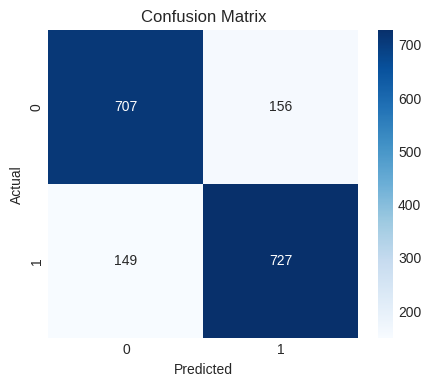

In [30]:
val_pred = model.predict(X_val)
val_pred = np.array(val_pred).astype(int).reshape(-1)

val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", round(val_acc, 5))

print("\nClassification Report")
print(classification_report(y_val, val_pred))

cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 14. 변수 중요도 확인

- 모델의 변수 중요도를 확인한 결과, Spa, CabinNum, VRDeck, Deck 등이 상위 변수로 나타났다.
- 이는 승객의 객실 위치 정보와 소비 성향이 Transported 여부를 예측하는 데 중요한 역할을 한다는 것을 의미한다.
- 특히 Cabin을 Deck, CabinNum, Side로 분해한 전처리와 소비 변수 기반 피처 활용이 모델 성능 향상에 기여했음을 확인할 수 있었다.

,feature,importance
8,Spa,12.486374
16,CabinNum,9.804849
9,VRDeck,9.772190
15,Deck,9.388930
18,TotalSpend,8.821924
6,FoodCourt,8.674994
0,HomePlanet,6.844660
17,Side,5.689903
5,RoomService,5.353492
7,ShoppingMall,5.105687


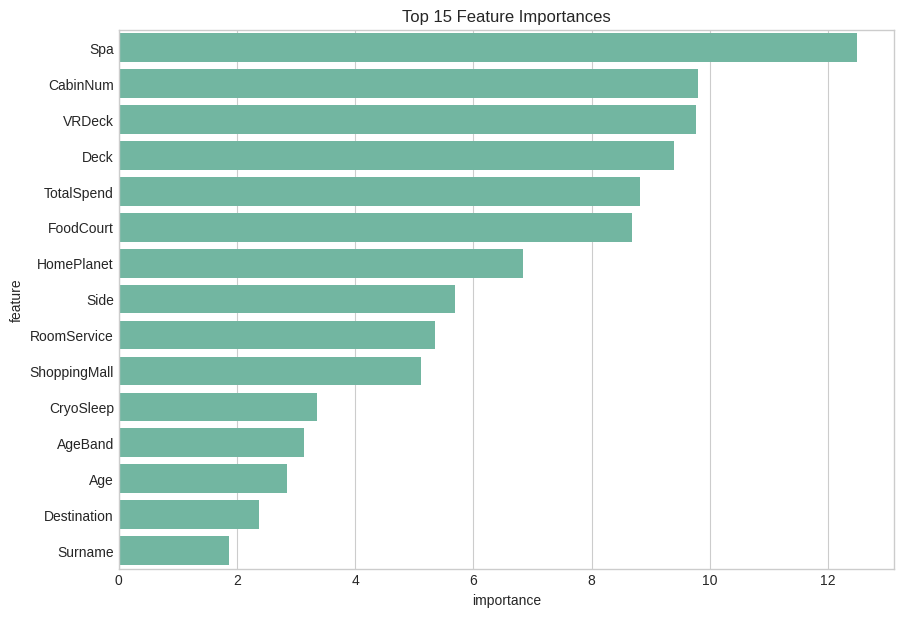

In [31]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Feature Importances")
plt.show()

# 15. 테스트 데이터 예측 및 제출 파일 생성

In [32]:
test_pred = model.predict(X_test)
test_pred = np.array(test_pred).astype(bool).reshape(-1)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": test_pred
})

submission.to_csv("submission.csv", index=False)
display(submission.head())

print("submission.csv saved")

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


submission.csv saved


# 16. Summary

- 본 분석에서는 결측치가 포함된 승객 데이터를 대상으로 전처리, 시각화, 피처 엔지니어링을 수행했다.
- 특히 Cabin 분해, 그룹 정보 추출, TotalSpend 생성, CryoSleep 논리 보정이 핵심 전처리였다.
- CatBoost 분류 모델을 적용하여 안정적인 검증 성능을 확보했고, Kaggle Public Score 0.805 이상을 목표로 하는 제출 파일을 생성했다.

# 17. 회고

이번 과제를 통해 데이터 분석을 기반으로 한 전처리 과정이 점수에 매우 큰 영향을 준다는 점을 느꼈다. 결측치 보정이나 파생변수 생성 같은 전처리 과정이 모델 성능 향상에 크게 기여했다. 또한 데이터의 종류와 특성에 따라 적절한 모델을 선택하는 것이 중요하다는 점도 함께 배울 수 있었다.

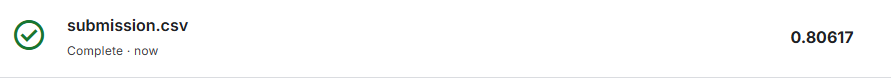